In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_palette('husl')
sns.set_style("ticks")

## 1. Fetch Data from W&B

Configure your W&B project and run details below:

In [2]:
# W&B Configuration
WANDB_PROJECT = "exact"
WANDB_ENTITY = "assistive-autonomy"

# Fetch specific run by name or ID
RUN_NAME = "activity_20260112_133637"  # e.g., "verbs_20251223_131604" or None to use latest
RUN_ID = "7cur3i6e"    # e.g., "1c5f755e" or None

In [3]:
def fetch_wandb_data(project: str, entity: str, run_name: str = None, run_id: str = None):
    """
    Fetch assessment data from W&B.
    
    Returns:
        dict with activities, score_matrix, auc values, separation values
    """
    api = wandb.Api()
    
    # Find the run
    if run_id:
        run = api.run(f"{entity}/{project}/{run_id}")
    else:
        # Get runs and filter
        runs = api.runs(f"{entity}/{project}")
        if run_name:
            runs = [r for r in runs if r.name == run_name]
        if not runs:
            raise ValueError(f"No runs found matching criteria")
        run = runs[0]  # Most recent
    
    print(f"Found run: {run.name} (ID: {run.id})")
    print(f"State: {run.state}")
    
    # Get summary metrics
    summary = run.summary._json_dict
    
    # Fetch the results table (per-activity metrics)
    results_df = None
    try:
        for artifact in run.logged_artifacts():
            if artifact.type == "run_table":
                for file in artifact.files():
                    if "results_table" in file.name:
                        table_path = artifact.download()
                        table_file = Path(table_path) / file.name
                        with open(table_file) as f:
                            table_data = json.load(f)
                        results_df = pd.DataFrame(table_data["data"], columns=table_data["columns"])
                        print(f"Loaded results_table with {len(results_df)} activities")
                        break
    except Exception as e:
        print(f"Could not fetch results_table from artifacts: {e}")
    
    # Fetch the separability matrix table
    matrix_df = None
    try:
        for artifact in run.logged_artifacts():
            if artifact.type == "run_table":
                for file in artifact.files():
                    if "separability_matrix" in file.name:
                        table_path = artifact.download()
                        table_file = Path(table_path) / file.name
                        with open(table_file) as f:
                            table_data = json.load(f)
                        matrix_df = pd.DataFrame(table_data["data"], columns=table_data["columns"])
                        print(f"Loaded separability_matrix ({len(matrix_df)}x{len(matrix_df)})")
                        break
    except Exception as e:
        print(f"Could not fetch separability_matrix from artifacts: {e}")
    
    return {
        "run": run,
        "summary": summary,
        "config": run.config,
        "results_df": results_df,
        "matrix_df": matrix_df,
    }


def parse_wandb_data(wandb_data: dict):
    """
    Parse W&B data into the format expected by plotting functions.
    
    Returns:
        dict with activities, score_matrix, auc_matrix, separation_vector, n_models
    """
    results_df = wandb_data["results_df"]
    matrix_df = wandb_data["matrix_df"]
    summary = wandb_data["summary"]
    
    # Get activities from matrix (first column is model_trained_on)
    activities = matrix_df["model_trained_on"].tolist()
    n = len(activities)
    
    # Build score matrix from matrix_df
    score_matrix = np.zeros((n, n))
    for i, row in matrix_df.iterrows():
        for j, act in enumerate(activities):
            val = row[act]
            score_matrix[i, j] = val if val is not None else np.nan
    
    # Build separation vector from results_df
    separation_vector = np.full(n, np.nan)
    for i, act in enumerate(activities):
        match = results_df[results_df["activity"] == act]
        if len(match) > 0:
            val = match["separation"].iloc[0]
            separation_vector[i] = val if val is not None else np.nan
    
    # Build AUC matrix (only diagonal from results_df)
    auc_matrix = np.full((n, n), np.nan)
    for i, act in enumerate(activities):
        match = results_df[results_df["activity"] == act]
        if len(match) > 0:
            val = match["auc"].iloc[0]
            auc_matrix[i, i] = val if val is not None else np.nan
    
    n_models = summary.get("n_models", n)
    
    return {
        "activities": activities,
        "score_matrix": score_matrix,
        "auc_matrix": auc_matrix,
        "separation_vector": separation_vector,
        "n_models": n_models,
    }

In [4]:
# Fetch data from W&B
wandb_data = fetch_wandb_data(WANDB_PROJECT, WANDB_ENTITY, RUN_NAME, RUN_ID)

print("\nSummary metrics:")
for key in ["mean_auc", "std_auc", "mean_separation", "std_separation", "n_models"]:
    if key in wandb_data["summary"]:
        val = wandb_data["summary"][key]
        if isinstance(val, float):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

# Parse W&B data into the format for plotting
data = parse_wandb_data(wandb_data)
print(f"\nLoaded {data['n_models']} models for {len(data['activities'])} activities")
print(f"Activities: {data['activities']}")

Found run: activity_20260112_133637 (ID: 7cur3i6e)
State: finished


wandb:   1 of 1 files downloaded.  


Loaded results_table with 6 activities


wandb:   1 of 1 files downloaded.  


Loaded separability_matrix (6x6)

Summary metrics:
  mean_auc: 0.5046
  std_auc: 0.0756
  mean_separation: 0.2560
  std_separation: 0.4745
  n_models: 6

Loaded 6 models for 6 activities
Activities: ['cleaning', 'cooking', 'experimental procedure', 'getting ready', 'other_annot', 'preparing ingredients']


## 2. Customizable Separability Matrix Plot

Adjust colors, fonts, and styling below:

In [5]:
# === PLOT CONFIGURATION ===

# Figure settings
FIGSIZE = (12, 10)
DPI = 150

# Color palette for heatmap
# Options: 'RdYlGn', 'viridis', 'plasma', 'coolwarm', 'RdBu_r', 'YlGnBu'
CMAP = 'coolwarm'

# Font settings
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 15
TICK_FONTSIZE = 13
ANNOT_FONTSIZE = 13

# Annotation settings
SHOW_VALUES = True           # Show numeric values in cells
VALUE_FORMAT = '.1f'         # Format for values
HIGHLIGHT_DIAGONAL = False    # Bold diagonal values

# Normalization
NORMALIZE_ROWS = True        # Normalize each row for relative comparison

In [14]:
def plot_separability_matrix(
    activities: list,
    score_matrix: np.ndarray,
    title: str = "Activity Separability Matrix",
    cmap: str = CMAP,
    figsize: tuple = FIGSIZE,
    normalize_rows: bool = NORMALIZE_ROWS,
    show_values: bool = SHOW_VALUES,
    save_path: str = None,
):
    """
    Plot separability matrix as a customizable heatmap.
    
    The matrix shows how each model (row) scores each activity (column).
    Diagonal should be highest for good separability.
    
    Note: Colors are based on row-normalized values (0-1) for visual comparison,
    but cell annotations show actual log-probability values.
    """
    n = len(activities)
    
    # Wrap activity labels by replacing spaces with newlines
    wrapped_activities = [act.replace(' ', '\n') for act in activities]
    wrapped_activities = [act.replace('_', '\n') for act in wrapped_activities]
    
    # Use original values for both coloring and annotation (no normalization)
    plot_matrix = score_matrix.copy()
    vmin, vmax = np.nanmin(plot_matrix), np.nanmax(plot_matrix)
    cbar_label = "Mean Log-Probability"
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap using seaborn for nicer styling
    mask = np.isnan(plot_matrix)
    
    sns.heatmap(
        plot_matrix,
        annot=score_matrix if show_values else False,  # Show original values
        fmt=VALUE_FORMAT if show_values else '',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        mask=mask,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': cbar_label, 'shrink': 0.8},
        annot_kws={'size': ANNOT_FONTSIZE},
        ax=ax,
    )
    
    # Highlight diagonal
    if HIGHLIGHT_DIAGONAL:
        for i in range(n):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1, fill=False, edgecolor='black', lw=2
            ))
    
    # Labels - use wrapped activities for better display
    ax.set_xticklabels(wrapped_activities, rotation=0, fontsize=TICK_FONTSIZE)
    ax.set_yticklabels(wrapped_activities, rotation=0, fontsize=TICK_FONTSIZE)
    ax.set_xlabel('Evaluated Activity', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylabel('Target Activity', fontsize=LABEL_FONTSIZE, fontweight='bold')
    # ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight', facecolor='white')
        print(f"Saved to: {save_path}")
    
    plt.show()
    return fig

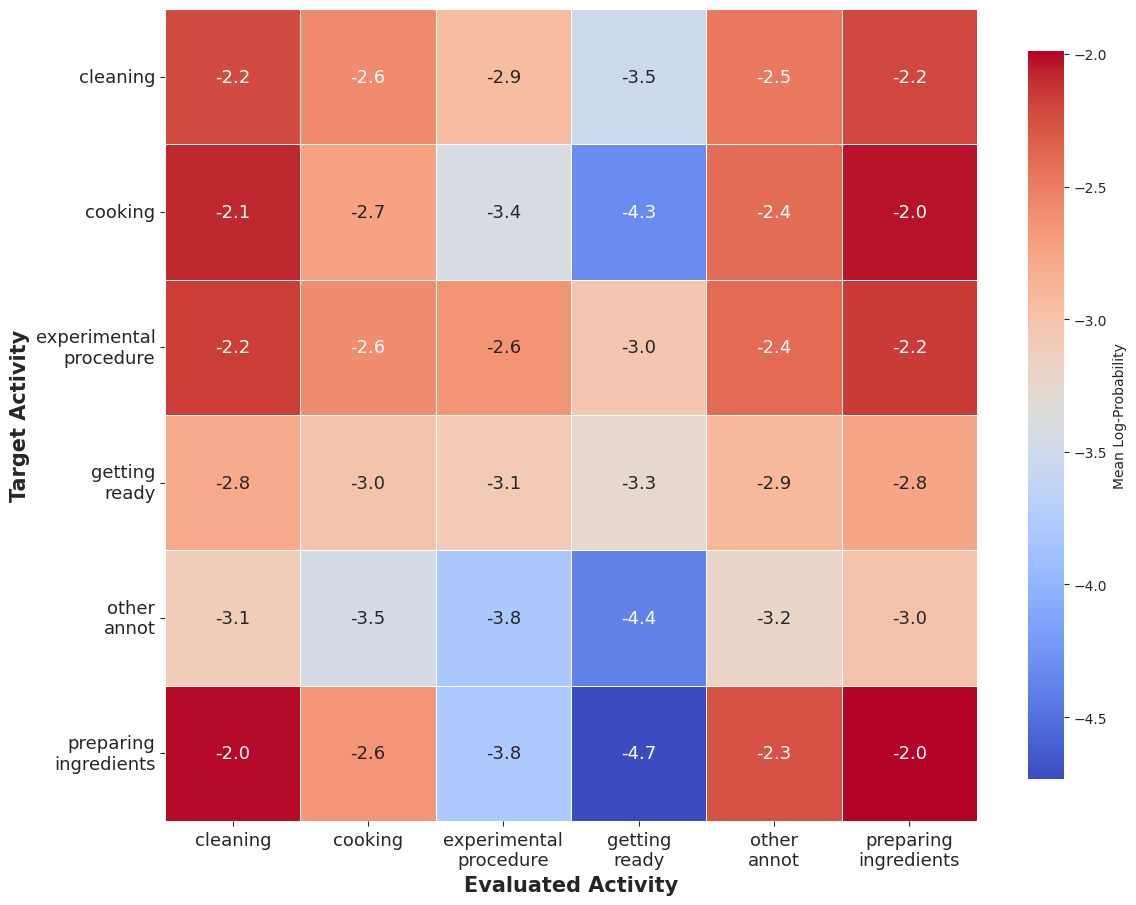

In [15]:
# Plot the separability matrix
fig_matrix = plot_separability_matrix(
    activities=data['activities'],
    score_matrix=data['score_matrix'],
    title="Activity Separability Matrix",
    # save_path="separability_matrix_custom.png",  # Uncomment to save
)

## 3. Separation & AUC Summary Plot

In [97]:
# === BAR CHART CONFIGURATION ===

# Colors
GOOD_COLOR = '#2ecc71'       # Green for positive/good values
BAD_COLOR = '#e74c3c'        # Red for negative/bad values
NEUTRAL_COLOR = '#95a5a6'    # Gray for neutral

# Thresholds
SEP_THRESHOLD = 0            # Separation threshold (0 = equal)
AUC_THRESHOLD = 0.5          # AUC threshold (0.5 = random)

In [ ]:
def plot_separation_summary(
    activities: list,
    separation_vector: np.ndarray,
    auc_matrix: np.ndarray,
    title: str = "Per-Activity Separation & AUC",
    figsize: tuple =  (7,6.5),
    save_path: str = None,
):
    """
    Plot bar charts of separation scores and AUC per activity.
    """
    n = len(activities)
    auc_diag = np.diag(auc_matrix)
    
    fig, axes = plt.subplots(2,1, figsize=figsize)
    
    # --- Separation Scores ---
    ax1 = axes[0]
    valid_sep = ~np.isnan(separation_vector)
    colors_sep = [GOOD_COLOR if s > SEP_THRESHOLD else BAD_COLOR 
                  for s in separation_vector]
    
    bars1 = ax1.bar(
        np.arange(n)[valid_sep], 
        separation_vector[valid_sep],
        color=[c for c, v in zip(colors_sep, valid_sep) if v],
        edgecolor='black',
        linewidth=0.5,
    )
    
    ax1.set_xticks(np.arange(n))
    ax1.set_ylim(-0.4,0.8)
    ax1.set_xticklabels(activities, rotation=0, fontsize=TICK_FONTSIZE)
    ax1.set_ylabel('Separation (Δ log p, nats)', fontsize=LABEL_FONTSIZE)
    ax1.axhline(y=SEP_THRESHOLD, color='black', linestyle='-', linewidth=1, alpha=0.7)
    ax1.grid(axis='both', alpha=0.75, linestyle='--')
    
    # Add value labels with offset
    for i, (v, val) in enumerate(zip(valid_sep, separation_vector)):
        if v:
            offset = 0.02 if val > 0 else -0.02  # Add spacing from bar
            ax1.annotate(
                f'{val:.2f}',
                xy=(i, val + offset),
                ha='center',
                va='bottom' if val > 0 else 'top',
                fontsize=8,
            )
    
    # --- AUC Scores ---
    ax2 = axes[1]
    valid_auc = ~np.isnan(auc_diag)
    colors_auc = [GOOD_COLOR if a > AUC_THRESHOLD else BAD_COLOR 
                  for a in auc_diag]
    
    bars2 = ax2.bar(
        np.arange(n)[valid_auc], 
        auc_diag[valid_auc],
        color=[c for c, v in zip(colors_auc, valid_auc) if v],
        edgecolor='black',
        linewidth=0.5,
    )
    
    ax2.set_xticks(np.arange(n))
    ax2.set_xticklabels(activities, rotation=0, fontsize=TICK_FONTSIZE)
    ax2.set_ylabel('AUC (target vs others)', fontsize=LABEL_FONTSIZE)
    ax2.axhline(y=AUC_THRESHOLD, color='black', linestyle='--', linewidth=1, 
                alpha=0.7, label='Random')
    ax2.set_ylim(0, 1.05)  # Slightly increased to fit labels
    ax2.legend(loc='best')
    ax2.grid(axis='both', alpha=0.75, linestyle='--')
    
    # Add value labels with offset
    for i, (v, val) in enumerate(zip(valid_auc, auc_diag)):
        if v:
            ax2.annotate(
                f'{val:.2f}',
                xy=(i, val + 0.02),  # Add spacing from bar
                ha='center',
                va='bottom',
                fontsize=8,
            )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight', facecolor='white')
        print(f"Saved to: {save_path}")
    
    plt.show()
    return fig

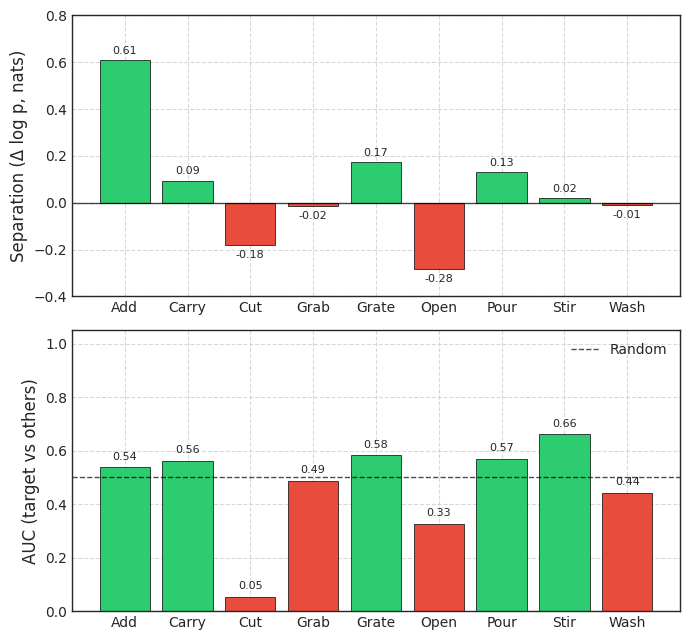

In [ ]:
# Plot separation summary
fig_summary = plot_separation_summary(
    activities=data['activities'],
    separation_vector=data['separation_vector'],
    auc_matrix=data['auc_matrix'],
    title="Per-Activity Metrics",
    # save_path="separation_summary_custom.png",  # Uncomment to save
)

## 5. Summary Statistics

## 6. Interpretation Guide

### How to Read the Separability Matrix

The separability matrix shows **mean log-probability** values:
- **Rows** = Model trained on that activity (Target Activity)
- **Columns** = Activity being evaluated (Evaluated Activity)
- **Cell values & colors** = Mean log-probability (same scale, shown on colorbar)

| Pattern | Interpretation |
|---------|---------------|
| **Bright diagonal (higher values)** | Models correctly assign high probability to their target activity ✓ |
| **Dark off-diagonal (lower values)** | Models correctly assign low probability to non-target activities ✓ |
| **Uniform rows** | Model cannot distinguish activities (bad) |
| **Bright column** | One activity looks "normal" to all models |
| **Dark column** | One activity is unusual to all models |

### Intuition for Log-Probability Values

The normalizing flow model outputs **log-probability** for each pose sequence:

- **Higher values** (closer to 0, e.g., -0.3): The model thinks this is "normal" / likely
- **Lower values** (more negative, e.g., -7.0): The model thinks this is "abnormal" / unlikely

The colorbar shows the actual log-probability scale. For example:
- A "Cut" model trained only on cutting motions should give:
  - **High scores** to cutting sequences (brighter color, e.g., ~-0.3)
  - **Low scores** to other activities (darker color, e.g., ~-4.0)

### Separation & AUC Metrics

**Separation Score** (class-balanced):
$$\text{Separation} = \log p_{\text{target}} - \frac{1}{N-1}\sum_{i \neq \text{target}} \log p_i$$

This is the difference between the target activity's mean log-probability and the **average of per-activity means** for all other activities. Each activity contributes equally regardless of sample count.

- **Positive (green)**: Model correctly assigns higher probability to its target ✓
- **Negative (red)**: Model assigns higher probability to other activities ✗
- **Larger positive values** = Better discrimination

**AUC (Area Under ROC Curve)**
- **AUC = 1.0**: Perfect separation between target and others
- **AUC > 0.7**: Good discrimination
- **AUC = 0.5**: Random chance (dashed line) — no discrimination
- **AUC < 0.5**: Worse than random (model is "reversed")

Note: AUC is inherently robust to class imbalance since it measures ranking performance.

### Common Issues

| Issue | Possible Cause |
|-------|---------------|
| Low AUC for all models | Activities are too similar, or model underfitting |
| One model has very low AUC | Not enough training data for that activity |
| Negative separation | Model learned wrong features or data issue |
| Uniform row in matrix | Model collapsed — not learning activity-specific features |